In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#!/usr/bin/env python3
"""
Test script for Avellaneda-Stoikov Market Making Strategy

This script demonstrates how to use the Avellaneda-Stoikov signal with the backtest driver
to run a complete market making strategy simulation.
"""

import datetime
import pandas as pd
import numpy as np
from gnomepy import Strategy, LatencyModel, SchemaBase, Order, OrderExecutionReport
from gnomepy.research.oms import LimitOrderOMS
from gnomepy.research.signals.avellaneda_stoikov import AvellanedaStoikovSignal
from gnomepy.backtest import (
    Backtest, 
    MBPSimulatedExchange,
    StaticLatency,
    RiskAverseQueueModel,
    OptimisticQueueModel,
    StaticFeeModel
)
from gnomepy.data.types import SchemaType, FIXED_PRICE_SCALE
from gnomepy.data.cached_client import CachedMarketDataClient
from gnomepy.registry.api import RegistryClient
from gnomepy.backtest.recorder import Recorder


print("=== Avellaneda-Stoikov Market Making Strategy Backtest ===\n")

# Configuration parameters
START_DATETIME = datetime.datetime(2026, 1, 15, 12, 0)
END_DATETIME = datetime.datetime(2026, 1, 16, 12, 0)
SCHEMA_TYPE = SchemaType.MBP_10
NOTIONAL = 0.1  # Base notional amount for trading

# Define listing IDs to trade
LISTING_IDS = [1]

# Avellaneda-Stoikov signal parameters
AV_STOIKOV_PARAMS = {
    'trade_frequency': 2,
    'volatility_window': 1000,
    'gamma': 2000,
    'order_arrival_rate': 7200,
    'max_inventory': 1
}

# Latency parameters (in nanoseconds)
STRATEGY_LATENCY = StaticLatency(1000)      # 1 microsecond strategy processing
NETWORK_LATENCY = StaticLatency(5000)       # 5 microseconds network latency
ORDER_PROCESSING_LATENCY = StaticLatency(2000)  # 2 microseconds order processing

print(f"Configuration set up for {len(LISTING_IDS)} listings from {START_DATETIME} to {END_DATETIME}")

=== Avellaneda-Stoikov Market Making Strategy Backtest ===

Configuration set up for 1 listings from 2026-01-15 12:00:00 to 2026-01-16 12:00:00


In [3]:
# Initialize clients
print("\n1. Initializing clients...")
market_data_client = CachedMarketDataClient(
    bucket="gnome-market-data-dev", 
    aws_profile_name="AWSAdministratorAccess-443370708724"
)
registry_client = RegistryClient(
    api_key="9WPV7CfeqXa578yVYlxdG3kCPFzACr7YaMU0UVma"
)


1. Initializing clients...


In [4]:
# Load listings from registry
print("\n2. Loading listings from registry...")
listings = []
for listing_id in LISTING_IDS:
    result = registry_client.get_listing(listing_id=listing_id)
    if not result:
        print(f"Warning: Unable to find listing_id: {listing_id}")
        continue
    listings.append(result[0])
    print(f"  Loaded listing: {result[0]}")

if not listings:
    raise ValueError("No valid listings found!")

print(f"Successfully loaded {len(listings)} listings")


2. Loading listings from registry...
  Loaded listing: Listing(listing_id=1, security_id=1, exchange_id=1, exchange_security_id='undefined', exchange_security_symbol='BTC', date_modified='2025-12-23T18:11:06.557Z', date_created='2025-12-23T18:11:06.557Z')
Successfully loaded 1 listings


In [5]:
# Create simulated exchanges for each listing
print("\n3. Creating simulated exchanges...")
exchanges = {}
for listing in listings:
    exchange_id = listing.exchange_id
    security_id = listing.security_id
    
    # Initialize exchange if not exists
    if exchange_id not in exchanges:
        exchanges[exchange_id] = {}
    
    # Create simulated exchange for this security
    exchanges[exchange_id][security_id] = MBPSimulatedExchange(
        fee_model=StaticFeeModel(taker_fee=0.002, maker_fee=0.0002),
        network_latency=NETWORK_LATENCY,
        order_processing_latency=ORDER_PROCESSING_LATENCY,
        queue_model=OptimisticQueueModel()
    )

print(f"Created simulated exchanges for {len(exchanges)} exchanges")


3. Creating simulated exchanges...
Created simulated exchanges for 1 exchanges


In [6]:
# Create Avellaneda-Stoikov signal
print("\n4. Creating Avellaneda-Stoikov signal...")
listing = listings[0]  # Avellaneda-Stoikov works with a single listing
avellaneda_stoikov_signal = AvellanedaStoikovSignal(
    listing=listing,
    data_schema_type=SCHEMA_TYPE,
    **AV_STOIKOV_PARAMS
)


4. Creating Avellaneda-Stoikov signal...
Initialized AvellanedaStoikovSignal for listing 1 (infinite horizon, EWM volatility)


In [7]:
# Create OMS with the signal
print("\n5. Creating LimitOrderOMS...")
oms = LimitOrderOMS(
    signals=[avellaneda_stoikov_signal],
    notional=NOTIONAL,
    position_aware_sizing=False,
    position_scaling_factor=0.3
)


5. Creating LimitOrderOMS...


In [8]:
# Create the strategy wrapper
print("\n6. Creating Strategy wrapper...")

class OMSStrategy(Strategy):
    """Generic strategy wrapper for OMS-based strategies."""
    
    def __init__(self, processing_latency: LatencyModel, oms):
        super().__init__(processing_latency)
        self.oms = oms

    def on_market_data(self, timestamp: int, data: SchemaBase, recorder: Recorder | None = None) -> list[Order]:
        return self.oms.on_market_update(timestamp, data, recorder)

    def on_execution_report(self, timestamp: int, execution_report: OrderExecutionReport, recorder: Recorder | None = None):
        self.oms.on_execution_report(timestamp, execution_report, recorder)

strategy = OMSStrategy(
    processing_latency=STRATEGY_LATENCY,
    oms=oms
)

print(f"Created OMSStrategy with Avellaneda-Stoikov signal")
print(f"Signal parameters: {AV_STOIKOV_PARAMS}")


6. Creating Strategy wrapper...
Created OMSStrategy with Avellaneda-Stoikov signal
Signal parameters: {'trade_frequency': 2, 'volatility_window': 1000, 'gamma': 2000, 'order_arrival_rate': 7200, 'max_inventory': 1}


In [9]:
# Create and initialize backtest
print("\n7. Creating backtest...")
backtest = Backtest(
    start_datetime=START_DATETIME,
    end_datetime=END_DATETIME,
    listing_ids=LISTING_IDS,
    schema_type=SCHEMA_TYPE,
    strategy=strategy,
    exchanges=exchanges,
    market_data_client=market_data_client,
    registry_client=registry_client
)
print("Backtest initialized successfully")
print(f"Backtest parameters:")
print(f"  - Start: {backtest.start_datetime}")
print(f"  - End: {backtest.end_datetime}")
print(f"  - Listings: {[l.listing_id for l in backtest.listings]}")
print(f"  - Schema: {backtest.schema_type}")


7. Creating backtest...
Backtest initialized successfully
Backtest parameters:
  - Start: 2026-01-15 12:00:00
  - End: 2026-01-16 12:00:00
  - Listings: [1]
  - Schema: mbp-10


In [10]:
# Prepare data and run backtest
print("\n8. Preparing market data...")
prep_start_time = datetime.datetime.now()
backtest.prepare_data()
prep_end_time = datetime.datetime.now()
prep_time = (prep_end_time - prep_start_time).total_seconds()
print(f"Data preparation completed in {prep_time:.2f} seconds")


8. Preparing market data...
Data preparation completed in 20.92 seconds


In [11]:
backtest.queue.get()

Event(timestamp=1768509869194000000, event_type=<EventType.EXCHANGE_MARKET_DATA: 0>, data=MBP10(exchange_id=1, security_id=1, timestamp_event=1768509869194000000, timestamp_sent=None, timestamp_recv=1768509895683109076, price=95225000000000, size=200, action='Trade', side='Ask', flags=['marketByPrice'], sequence=1768509869194000000, depth=None, levels=[BidAskPair(bid_px=95225000000000, ask_px=95226000000000, bid_sz=14952090, ask_sz=311120, bid_ct=35, ask_ct=1), BidAskPair(bid_px=95224000000000, ask_px=95227000000000, bid_sz=579180, ask_sz=240, bid_ct=6, ask_ct=2), BidAskPair(bid_px=95223000000000, ask_px=95228000000000, bid_sz=687780, ask_sz=240, bid_ct=9, ask_ct=2), BidAskPair(bid_px=95222000000000, ask_px=95229000000000, bid_sz=155430, ask_sz=130, bid_ct=11, ask_ct=1), BidAskPair(bid_px=95221000000000, ask_px=95230000000000, bid_sz=138030, ask_sz=240, bid_ct=9, ask_ct=2), BidAskPair(bid_px=95220000000000, ask_px=95231000000000, bid_sz=633240, ask_sz=130, bid_ct=7, ask_ct=1), BidAskPa

In [13]:
# Execute backtest
print("\n9. Executing backtest...")
exec_start_time = datetime.datetime.now()
backtest.fully_execute()
exec_end_time = datetime.datetime.now()
exec_time = (exec_end_time - exec_start_time).total_seconds()
print(f"Backtest execution completed in {exec_time:.2f} seconds")


9. Executing backtest...
Cash update - BUY: 990000.42 -> 980000.84 (trade value: 9999.58)
Cash update - BUY: 980000.84 -> 970001.26 (trade value: 9999.58)
Cash update - BUY: 970001.26 -> 960002.57 (trade value: 9998.69)
Cash update - BUY: 960002.57 -> 950002.62 (trade value: 9999.95)
Cash update - BUY: 950002.62 -> 940002.68 (trade value: 9999.95)
Cash update - BUY: 940002.68 -> 930002.73 (trade value: 9999.95)
Cash update - BUY: 930002.73 -> 920003.20 (trade value: 9999.53)
Cash update - BUY: 920003.20 -> 910003.99 (trade value: 9999.21)
Cash update - BUY: 910003.99 -> 900004.78 (trade value: 9999.21)
Cash update - SELL: 900004.78 -> 910005.30 (trade value: 10000.53)
Cash update - SELL: 910005.30 -> 920005.83 (trade value: 10000.53)
Cash update - SELL: 920005.83 -> 930006.35 (trade value: 10000.53)
Cash update - SELL: 930006.35 -> 940006.88 (trade value: 10000.53)
Cash update - SELL: 940006.88 -> 950007.35 (trade value: 10000.47)
Cash update - SELL: 950007.35 -> 960007.83 (trade valu

In [14]:
# Analyze results
print("\n=== Backtest Results ===")
print(f"Strategy: Avellaneda-Stoikov Market Making")
print(f"Trading period: {START_DATETIME} to {END_DATETIME}")
print(f"Number of listings: {len(listings)}")
print(f"Base notional: ${NOTIONAL:,.2f}")

# Access OMS state
print(f"\n=== OMS State ===")
print(f"Signal positions: {oms.signal_positions}")
print(f"Overall positions: {oms.positions}")
print(f"Number of signals: {len(oms.signals)}")

# Performance summary
print("\n=== Performance Summary ===")
print("✓ Backtest executed successfully")
print("✓ Avellaneda-Stoikov signal integrated with driver")
print("✓ Market data processed through OMS")
print("✓ Orders generated and executed")
print("✓ Position tracking active")


=== Backtest Results ===
Strategy: Avellaneda-Stoikov Market Making
Trading period: 2026-01-15 12:00:00 to 2026-01-16 12:00:00
Number of listings: 1
Base notional: $0.10

=== OMS State ===
Signal positions: {<gnomepy.research.signals.avellaneda_stoikov.signal.AvellanedaStoikovSignal object at 0x113c78ad0>: {1: -0.9440624002413845}}
Overall positions: {1: -0.9440624002413845}
Number of signals: 1

=== Performance Summary ===
✓ Backtest executed successfully
✓ Avellaneda-Stoikov signal integrated with driver
✓ Market data processed through OMS
✓ Orders generated and executed
✓ Position tracking active



10. Generating strategy statistics...
{'total_records': np.int64(284866), 'market_buffer_usage': {1: np.float64(0.712165)}, 'intent_buffer_usage': {1: np.float64(0.0)}, 'schema_type': 'mbp-10', 'assets': {1: {'market_record_count': 284866, 'market_timestamp_range': (1768509895681343853, 1768568399890904846), 'market_price_range': (95117.0, 95845.5)}}}


,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees
0,2026-01-15 20:44:55.681343853,2026-01-16 12:59:59.890904846,303.543208,1255.98564,0.001584,91.545574,1.062284,2.056867,0.241677


,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,listing_id
0,2026-01-15 20:44:55.681343853,2026-01-16 12:59:59.890904846,-902.950661,1255.98564,-0.004702,91.545574,1.064337,2.008646,-0.718918,1


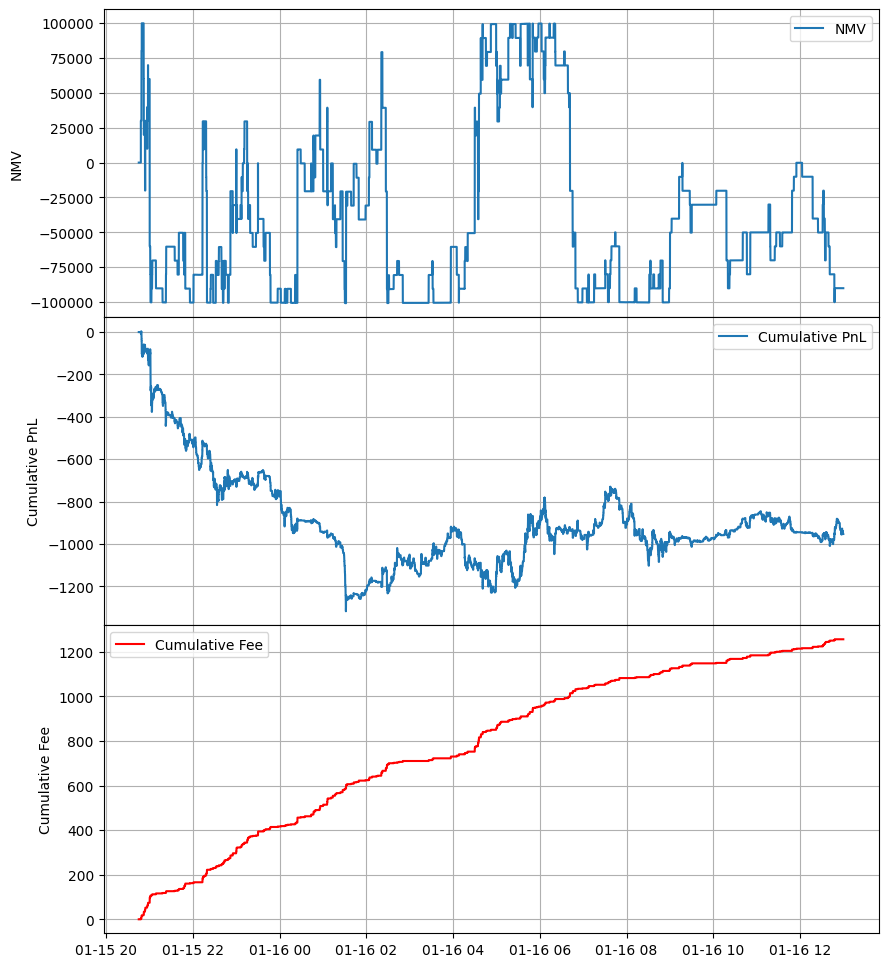

In [17]:
# Generate strategy statistics
print("\n10. Generating strategy statistics...")
from gnomepy.backtest.stats.strategy import StrategyStats

print(backtest.recorder.get_summary_stats())

strat_sts = StrategyStats(
    {
        listing_id: backtest.recorder.get_record(listing_id).stats()
        for listing_id in LISTING_IDS
    },
)
    
display(strat_sts.summary())
display(strat_sts.listing_summary())
strat_sts.plot()


11. Visualizing listing stats...
Listing ID: 1


,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees
0,2026-01-15 20:44:55.681343853,2026-01-16 12:59:59.890904846,-902.950661,1255.98564,-0.004702,91.545574,1.064337,2.008646,-0.718918


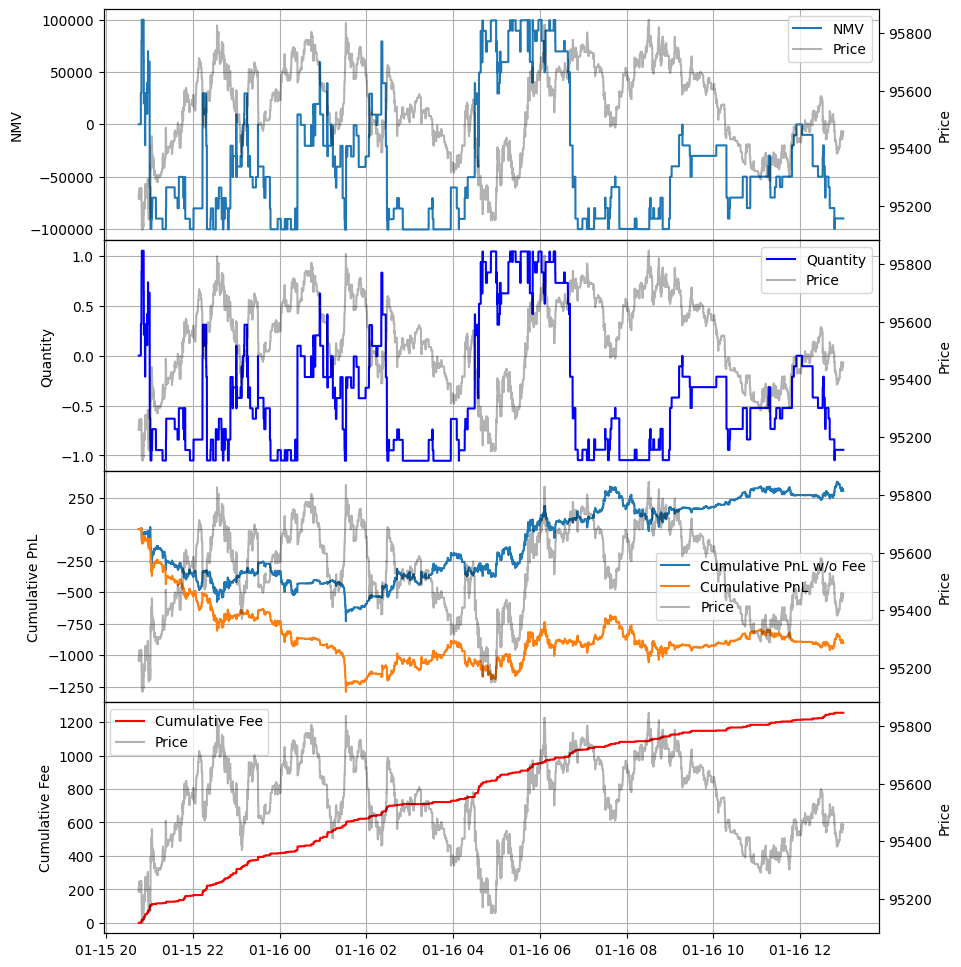

In [18]:
# Visualize listing-level statistics
print("\n11. Visualizing listing stats...")
sts = {}
for listing_id in LISTING_IDS:
    print(f"Listing ID: {listing_id}")
    listing_sts = backtest.recorder.get_record(listing_id).stats()
    sts[listing_id] = listing_sts
    display(listing_sts.summary())
    display(listing_sts.plot())

In [19]:
# Analyze model values (optimal prices, reservation price, etc.)
print("\n12. Analyzing Avellaneda-Stoikov model values...")
df = avellaneda_stoikov_signal.model_value_recorder.get_record(1).df
display(df.head(100))

#df['bid_spread'] = df['optimal_bid'] - df['best_bid'] 
df['tmp_spread'] = df['best_ask'] - df['best_bid']

#df[['tmp_spread']].plot(title='Reservation Price Over Time')

ts = df.sort_values(by='tmp_spread', ascending=False).index.values[0]


12. Analyzing Avellaneda-Stoikov model values...


,mid_price,inventory,volatility,optimal_bid,optimal_ask,reservation_price,spread,best_bid,best_ask
timestamp,,,,,,,,,
2026-01-15 20:47:41.990884911,95261.5,0.000000,0.000025,95261.499877,95261.500123,95261.5,1.0,95261.0,95262.0
2026-01-15 20:47:42.390911014,95261.5,0.000000,0.000024,95261.499877,95261.500123,95261.5,1.0,95261.0,95262.0
2026-01-15 20:47:43.591350248,95261.5,0.000000,0.000024,95261.499877,95261.500123,95261.5,1.0,95261.0,95262.0
2026-01-15 20:47:45.190922877,95261.5,0.000000,0.000024,95261.499877,95261.500123,95261.5,1.0,95261.0,95262.0
2026-01-15 20:47:45.791405832,95261.5,0.000000,0.000024,95261.499877,95261.500123,95261.5,1.0,95261.0,95262.0
...,...,...,...,...,...,...,...,...,...
2026-01-15 20:48:10.280838608,95243.5,0.314997,0.000025,95243.499877,95243.500123,95243.5,1.0,95243.0,95244.0
2026-01-15 20:48:11.080717415,95243.5,0.314997,0.000025,95243.499877,95243.500123,95243.5,1.0,95243.0,95244.0
2026-01-15 20:48:12.280741655,95243.5,0.314997,0.000025,95243.499877,95243.500123,95243.5,1.0,95243.0,95244.0


In [20]:
# Analyze PnL and fees
print("\n13. Analyzing PnL and fees...")
pnl_summary = backtest.recorder.get_record(1).df.pipe(
    lambda df: df[['pnl', 'pnl_wo_fee', 'fee']].sum()
)
display(pnl_summary)


13. Analyzing PnL and fees...


pnl           -902.950661
pnl_wo_fee     303.543208
fee           1255.985640
dtype: float64

In [21]:
# Analyze trading intents
print("\n14. Analyzing trading intents...")
df = backtest.recorder.get_intent_record(1).df
#df['timestamp'] = pd.to_datetime(df.timestamp)
intents_with_confidence = df#[df.confidence > 0.1]
display(intents_with_confidence.head())
df


14. Analyzing trading intents...


,side,confidence,price,flatten,is_buy,is_sell
timestamp,,,,,,


,side,confidence,price,flatten,is_buy,is_sell
timestamp,,,,,,


In [29]:
ts = backtest.recorder.get_record(1).df.pipe(lambda d: d[d.event == 2].index[4])
idx = backtest.recorder.get_record(1).df.index.get_loc(ts)
backtest.recorder.get_record(1).df.iloc[idx - 5:idx + 10]

,event,price,fill_price,quantity,fee,nmv,pnl_wo_fee,spread_pnl,pnl
timestamp,,,,,,,,,
2026-01-15 20:48:42.482713917,1.0,95216.5,95216.5,0.419989,0.000000,39989.867804,0.000000,0.000000,0.000000
2026-01-15 20:48:42.880728677,1.0,95215.5,95215.5,0.419989,0.000000,39989.447815,-0.419989,0.000000,-0.419989
2026-01-15 20:48:42.880741677,2.0,95215.5,95216.0,0.525013,1.999989,49989.342791,0.000000,0.052512,-1.947478
2026-01-15 20:48:42.880769922,1.0,95215.5,95215.5,0.525013,0.000000,49989.342791,0.000000,0.000000,0.000000
2026-01-15 20:48:43.180724459,1.0,95215.5,95215.5,0.525013,0.000000,49989.342791,0.000000,0.000000,0.000000
2026-01-15 20:48:43.180737459,2.0,95212.5,95215.0,0.630038,1.999989,59987.452679,-1.575038,0.262562,-3.312465
2026-01-15 20:48:43.480723319,1.0,95212.5,95212.5,0.630038,0.000000,59987.452679,0.000000,0.000000,0.000000
2026-01-15 20:48:43.480736319,2.0,95212.5,95215.0,0.735062,1.999989,69987.137604,0.000000,0.262562,-1.737427
2026-01-15 20:48:43.682174555,1.0,95212.5,95212.5,0.735062,0.000000,69987.137604,0.000000,0.000000,0.000000


In [22]:
backtest.recorder.market_recorder.get_record(1).df.head(250).tail(50)

,event,price,quantity,fee,nmv,pnl_wo_fee,pnl
timestamp,,,,,,,
2026-01-15 20:46:04.680829855,1.0,95260.5,0.0,0.0,0.0,0.0,0.0
2026-01-15 20:46:04.680857795,1.0,95260.5,0.0,0.0,0.0,0.0,0.0
2026-01-15 20:46:04.680914496,1.0,95260.5,0.0,0.0,0.0,0.0,0.0
2026-01-15 20:46:04.980730642,1.0,95260.5,0.0,0.0,0.0,0.0,0.0
2026-01-15 20:46:05.382220215,1.0,95259.5,0.0,0.0,0.0,-0.0,-0.0
2026-01-15 20:46:05.980744963,1.0,95259.5,0.0,0.0,0.0,0.0,0.0
2026-01-15 20:46:06.581140786,1.0,95259.5,0.0,0.0,0.0,0.0,0.0
2026-01-15 20:46:06.680737548,1.0,95259.5,0.0,0.0,0.0,0.0,0.0
2026-01-15 20:46:07.080743694,1.0,95259.5,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Optional: Save backtest results
# backtest.recorder.to_npz("avellaneda_stoikov_backtest.npz")

In [ ]:
# Optional: Calibrate parameters
print("\n15. Optional: Parameter calibration...")
print("To calibrate optimal parameters, use the calibrate.py script:")
print("  python calibrate.py --listing_id 1 --start_date 2025-12-25 --end_date 2025-12-26")

In [28]:
# Example: Parameter calibration (optional)
# Uncomment and run this cell to calibrate optimal parameters

from gnomepy.research.signals.avellaneda_stoikov.calibrate import AvellanedaStoikovCalibrator

calibrator = AvellanedaStoikovCalibrator(
    market_data_client=market_data_client,
    listing_id=LISTING_IDS[0],
    start_datetime=START_DATETIME,
    end_datetime=END_DATETIME,
    schema_type=SCHEMA_TYPE,
)


results = calibrator.calibrate(
    volatility_window=1000,
    optimize_gamma=False,
    order_arrival_rate_method='spread_based',
    optimize_volatility_window=True,
    target_inventory_risk=0.01,
)

recommended = calibrator.get_recommended_parameters()
print("\n=== Recommended Parameters ===")
for key, value in recommended.items():
    print(f"{key}: {value}")


=== Calibrating Avellaneda-Stoikov Parameters ===

Loading market data for listing 1...
  Period: 2026-01-15 12:00:00 to 2026-01-16 12:00:00
Loaded 284172 market data points
  Price range: $95117.00 - $95845.50
1. Optimizing volatility window...
   Top 3 volatility window candidates:
     Window 1000: score=-7.2987, vol_of_vol=0.929166, mean_vol=0.000025
     Window 947: score=-7.4948, vol_of_vol=0.948811, mean_vol=0.000025
     Window 895: score=-7.6972, vol_of_vol=0.969092, mean_vol=0.000024
   Optimal volatility window: 1000

2. Calculating volatility (per tick)...
   Mean volatility (per tick): 0.000025
   Volatility range (per tick): 0.000001 - 0.000160

3. Estimating/optimizing order arrival rate (orders per tick)...
   Estimated order arrival rate (k): 7162.4021 orders/tick
   k range: 1175.769089 - 9486.024617 orders/tick

4. Calculating optimal gamma...
Gamma: 2262.041890235879
Target inventory risk: 0.01
Volatility: 2.4843931790080287e-05
Order arrival rate: 7162.40212489186